# M1: Road Network — RTIG Interurban Roads
## IE Sustainability Datathon March 2026, Iberdrola Challenge

**Objective:** Download, clean, and export the RTIG (Red de Transporte de Interés
General) road network as a filtered GeoJSON, retaining only roads eligible for the
interurban EV charging network analysis.

**Eligible road types (per datathon guidelines):**
- Autopistas (AP- roads) — toll motorways  
- Autovías (A- roads) — free dual carriageways  
- Carreteras nacionales (N- roads) — national roads

**Data source:** Ministry of Transport and Sustainable Mobility (MITMA) REST API  
→ Endpoint: `mapas.fomento.gob.es/arcgis2/rest/services/Hermes/0_CARRETERAS/MapServer/19`  
→ Direct portal under maintenance; REST API workaround documented in  
`references/dataset_download_workaround.txt`  
→ Total records available: 1,602

**Output:** `Data/raw/road_routes_spain/carreteras_RTIG.geojson`  
→ Consumed by **M4** (station placement and File 2.csv generation)

---
**Fork reference (mandatory):** https://github.com/NOSIEMPRE/Laboratorio-de-Datos

## 0. Setup: Install Dependencies

In [1]:
# !pip install geopandas shapely requests matplotlib -q


In [2]:
import os
import json
import time

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import LineString, MultiLineString

# ── API configuration (per dataset_download_workaround.txt) ──────────────────
API_BASE = (
    'https://mapas.fomento.gob.es/arcgis2/rest/services'
    '/Hermes/0_CARRETERAS/MapServer/19/query'
)
BATCH_SIZE     = 500
TOTAL_EXPECTED = 1602
OUTPUT_DIR     = '../Data/raw/road_routes_spain'
OUTPUT_PATH    = os.path.join(OUTPUT_DIR, 'carreteras_RTIG.geojson')

print('Dependencies loaded successfully.')
print(f'API endpoint : {API_BASE}')
print(f'Output file  : {OUTPUT_PATH}')

Dependencies loaded successfully.
API endpoint : https://mapas.fomento.gob.es/arcgis2/rest/services/Hermes/0_CARRETERAS/MapServer/19/query
Output file  : ../Data/raw/road_routes_spain/carreteras_RTIG.geojson


## 1. Download Road Network from REST API

The MITMA direct-download portal is under maintenance. Per
`dataset_download_workaround.txt`, the full dataset is accessible via the
ArcGIS REST API using paginated queries (500 records per batch, 4 batches
for the 1,602 total records).

**Key query parameters:**
- `outSR=4326` — return coordinates in WGS84 (lon/lat) directly, avoiding
  a downstream reprojection step
- `outFields=*` — return all available attribute fields
- `resultOffset` — pagination cursor, incremented by 500 per batch

Available fields in the dataset: `id`, `Carretera`, `Longitud`, `PK_inicio`,
`PK_fin`, `Tipo_de_via`, `Valido_desde`, `Valido_hasta`, `Titular`, `TENT`,
`TENT_red_basica`, `TENT_corredor`.

In [3]:
params_base = {
    'where'            : 'id>0',
    'outFields'        : '*',
    'outSR'            : '4326',    # request WGS84 coordinates directly
    'returnGeometry'   : 'true',
    'f'                : 'json',
    'resultRecordCount': BATCH_SIZE,
}

all_features = []
offset = 0

print('Downloading RTIG road network from MITMA REST API ...')
while True:
    params = {**params_base, 'resultOffset': offset}
    r = requests.get(API_BASE, params=params, timeout=60)
    r.raise_for_status()

    batch = r.json().get('features', [])
    n = len(batch)
    all_features.extend(batch)
    end_idx = offset + n - 1
    print(f'  Records {offset:>4}–{end_idx:<4}  →  {n} received  |  Total: {len(all_features)}')

    if n < BATCH_SIZE:
        print('Last batch — download complete.')
        break
    offset += BATCH_SIZE
    time.sleep(0.5)   # respectful pacing to avoid rate-limiting

if len(all_features) != TOTAL_EXPECTED:
    print(f'WARNING: expected {TOTAL_EXPECTED} records, got {len(all_features)}')
else:
    print(f'✓ {len(all_features)} records downloaded (matches expected total of {TOTAL_EXPECTED})')

  Records    0–499   →  500 received  |  Total: 500
  Records  500–999   →  500 received  |  Total: 1000
  Records 1000–1499  →  500 received  |  Total: 1500
  Records 1500–1601  →  102 received  |  Total: 1602
Last batch — download complete.
✓ 1602 records downloaded (matches expected total of 1602)


## 2. Build GeoDataFrame

Parse the raw ArcGIS JSON features into a GeoPandas GeoDataFrame.

**Geometry format:** ArcGIS REST API returns polyline features as
`{"paths": [[[lon, lat], ...]]}`. Single-path features become a Shapely
`LineString`; multi-path features become a `MultiLineString`.

**CRS:** Because we requested `outSR=4326`, the coordinates are already in
WGS84 — no reprojection needed at this stage.

In [4]:
def parse_esri_polyline(geom):
    '''Convert an ESRI JSON polyline dict to a Shapely geometry.'''
    if not geom:
        return None
    paths = geom.get('paths', [])
    if not paths:
        return None
    if len(paths) == 1:
        coords = paths[0]
        return LineString(coords) if len(coords) >= 2 else None
    # Multiple paths → MultiLineString
    valid_paths = [p for p in paths if len(p) >= 2]
    return MultiLineString(valid_paths) if valid_paths else None


records = []
for feat in all_features:
    row = dict(feat.get('attributes', {}))
    row['geometry'] = parse_esri_polyline(feat.get('geometry'))
    records.append(row)

gdf_raw = gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')

n_null = gdf_raw.geometry.isna().sum()
if n_null > 0:
    print(f'NOTE: Dropping {n_null} records with null geometry.')
    gdf_raw = gdf_raw.dropna(subset=['geometry']).reset_index(drop=True)

print(f'GeoDataFrame shape : {gdf_raw.shape}')
print(f'CRS                : {gdf_raw.crs}')
print(f'Columns            : {gdf_raw.columns.tolist()}')
print()
print(gdf_raw[['Carretera', 'Tipo_de_via', 'Longitud', 'PK_inicio', 'PK_fin']].head())

GeoDataFrame shape : (1602, 13)
CRS                : EPSG:4326
Columns            : ['id', 'Carretera', 'Longitud', 'PK_inicio', 'PK_fin', 'Tipo_de_via', 'Valido_desde', 'Valido_hasta', 'Titular', 'TENT', 'TENT_red_basica', 'TENT_corredor', 'geometry']

  Carretera             Tipo_de_via  Longitud  PK_inicio   PK_fin
0     A-66R  Carretera convencional      1119    149.430  150.375
1     A-66R  Carretera convencional       916    152.340  152.960
2     A-66R  Carretera convencional      1633    182.375  184.015
3     TO-23             Multicarril      7528     -0.370    7.055
4     AP-7S         Autopista peaje     22078    133.480  154.000


## 3. Explore Road Types

Before applying the eligibility filter, we inspect the `Tipo_de_via` field to
understand the exact label vocabulary used by MITMA. The workaround doc mentions
four road categories: *toll motorway*, *free motorway/dual carriageway*,
*multi-lane road*, and *conventional road*. This cell confirms the exact Spanish
text labels and which road designations fall under each type.

In [5]:
print('=' * 60)
print('  ROAD TYPE DISTRIBUTION (Tipo_de_via)')
print('=' * 60)
vc_tipo = gdf_raw['Tipo_de_via'].value_counts(dropna=False)
for tipo, count in vc_tipo.items():
    print(f'  {str(tipo):<40}  {count:>5} segments')

print()
print('=' * 60)
print('  SAMPLE ROAD NAMES BY TYPE')
print('=' * 60)
for tipo in vc_tipo.index:
    samples = sorted(
        gdf_raw[gdf_raw['Tipo_de_via'] == tipo]['Carretera']
        .dropna().unique()
    )[:8]
    print(f'\n  {tipo}:')
    print(f'    {samples}')

print()
print('=' * 60)
print('  TOP 20 MOST COMMON ROAD DESIGNATIONS')
print('=' * 60)
print(gdf_raw['Carretera'].value_counts().head(20).to_string())

  ROAD TYPE DISTRIBUTION (Tipo_de_via)
  Carretera convencional                      789 segments
  Autopista libre\Autovía                     534 segments
  Multicarril                                 189 segments
  Autopista peaje                              79 segments
  nan                                          11 segments

  SAMPLE ROAD NAMES BY TYPE

  Carretera convencional:
    ['A-11R', 'A-14-R2', 'A-22-R1', 'A-22-R2', 'A-26', 'A-384', 'A-4R1', 'A-63R']

  Autopista libre\Autovía:
    ['A-1', 'A-10', 'A-11', 'A-12', 'A-13', 'A-14', 'A-15', 'A-2']

  Multicarril:
    ['A-1A', 'A-2', 'A-45', 'A-4R2', 'A-55', 'A-68', 'A-73R', 'A-77A']

  Autopista peaje:
    ['A-7S', 'AP-1', 'AP-15', 'AP-15-R', 'AP-36', 'AP-41', 'AP-46', 'AP-51']

  nan:
    []

  TOP 20 MOST COMMON ROAD DESIGNATIONS
Carretera
N-340     37
N-630     28
N-340A    27
A-7S      26
N-634     26
N-432A    24
N-120     23
A-8       22
N-2       22
A-1       20
A-2       20
N-232A    20
N-6       19
A-23      18
A-

## 4. Filter to Eligible Road Types

The datathon guidelines restrict the analysis to **autopistas, autovías, and
carreteras nacionales** as classified by the Ministry of Transport dataset.

**Filter strategy — two independent criteria (OR logic):**

1. **Tipo_de_via motorway match** — any segment where `Tipo_de_via` contains
   `'autopista'`, `'autov'` (covers both *autovía* and *autovia* regardless of
   accent), or `'multicarril'`. This captures all AP- and A- roads regardless
   of the exact label wording used in the dataset.

2. **National road name match** — any segment whose designation starts with
   `'N-'` (carreteras nacionales). National roads can appear under
   `'Carretera convencional'` in `Tipo_de_via` (the workaround doc shows
   A-66R classified as *Carretera convencional*), so a name-prefix filter is
   applied as a complementary safety net.

**This dual criterion is documented here for the Analytical Report** (evaluation
criterion T1 requires all methodology decisions to be explicitly justified).

In [6]:
# ── Eligibility filter ───────────────────────────────────────────────────────
tipo_norm = gdf_raw['Tipo_de_via'].str.lower().str.strip().fillna('')

mask_motorway = (
    tipo_norm.str.contains('autopista',   na=False) |
    tipo_norm.str.contains('autov',       na=False) |   # autovía / autovia
    tipo_norm.str.contains('multicarril', na=False)
)

# N- prefix: carreteras nacionales may appear as 'Carretera convencional'
mask_nacional = gdf_raw['Carretera'].str.upper().str.startswith('N-', na=False)

mask = mask_motorway | mask_nacional
gdf  = gdf_raw[mask].copy().reset_index(drop=True)

n_kept     = len(gdf)
n_total    = len(gdf_raw)
n_excluded = n_total - n_kept
n_roads    = gdf['Carretera'].nunique()

print('ELIGIBILITY FILTER RESULTS')
print('-' * 50)
print(f'  Total RTIG records          : {n_total:>5}')
print(f'  Eligible roads (kept)       : {n_kept:>5}')
print(f'  Excluded                    : {n_excluded:>5}')
print()
print('  Breakdown of kept records by Tipo_de_via:')
for tipo, count in gdf['Tipo_de_via'].value_counts().items():
    print(f'    {str(tipo):<40}  {count:>5}')
print()
print(f'  Unique road designations    : {n_roads}')

ELIGIBILITY FILTER RESULTS
--------------------------------------------------
  Total RTIG records          :  1602
  Eligible roads (kept)       :  1535
  Excluded                    :    67

  Breakdown of kept records by Tipo_de_via:
    Carretera convencional                      722
    Autopista libre\Autovía                     534
    Multicarril                                 189
    Autopista peaje                              79

  Unique road designations    : 423


## 5. Network Summary and Segment Lengths

Compute segment lengths in metres by temporarily projecting to ETRS89 UTM Zone
30N (EPSG:25830) — Spain's standard metric reference system. The primary
geometry column remains in WGS84 (EPSG:4326).

The `length_m` column is retained in the export for use by M4, which will use
cumulative segment lengths to space charging stations at regular intervals.

In [7]:
# Project to metric CRS to compute lengths; main geometry stays in WGS84
gdf['length_m'] = gdf.to_crs('EPSG:25830').geometry.length
total_km    = gdf['length_m'].sum() / 1000
n_segments  = len(gdf)
n_unique    = gdf['Carretera'].nunique()

print('=' * 55)
print('  NETWORK SUMMARY')
print('=' * 55)
print(f'  Segments              : {n_segments:>6}')
print(f'  Unique road names     : {n_unique:>6}')
print(f'  Total network length  : {total_km:>6.0f} km')
print()

print('  By road type:')
by_type = (
    gdf.groupby('Tipo_de_via')
    .agg(
        segments=('Carretera', 'count'),
        roads=('Carretera', 'nunique'),
        length_km=('length_m', lambda x: x.sum() / 1000)
    )
    .round(1)
)
print(by_type.to_string())

print()
print('  Top 15 roads by total length (km):')
top15 = (
    gdf.groupby('Carretera')['length_m']
    .sum()
    .sort_values(ascending=False)
    .head(15) / 1000
).round(1)
print(top15.to_string())

  NETWORK SUMMARY
  Segments              :   1535
  Unique road names     :    423
  Total network length  :  29050 km

  By road type:
                         segments  roads  length_km
Tipo_de_via                                        
Autopista libre\Autovía       534    170    11798.9
Autopista peaje                79     31     2132.1
Carretera convencional        722    179    14290.0
Multicarril                   189    114      567.3

  Top 15 roads by total length (km):
Carretera
AP-7N    848.7
A-66     689.3
N-630    669.4
A-4      583.4
N-634    563.4
N-340    540.5
N-420    532.6
A-2      526.8
A-6      519.0
N-120    499.2
A-8      472.0
A-7S     455.9
N-260    441.7
N-232    431.8
N-234    420.6


## 6. Spatial Visualisation

Plot the filtered road network colour-coded by `Tipo_de_via`. This provides a
visual sanity check that the filter retained Spain's major interurban corridors
(A-4 to Cádiz, A-7 Mediterranean, AP-9 in Galicia, A-8 Cantábrico, etc.) and
did not over-include regional or local roads.

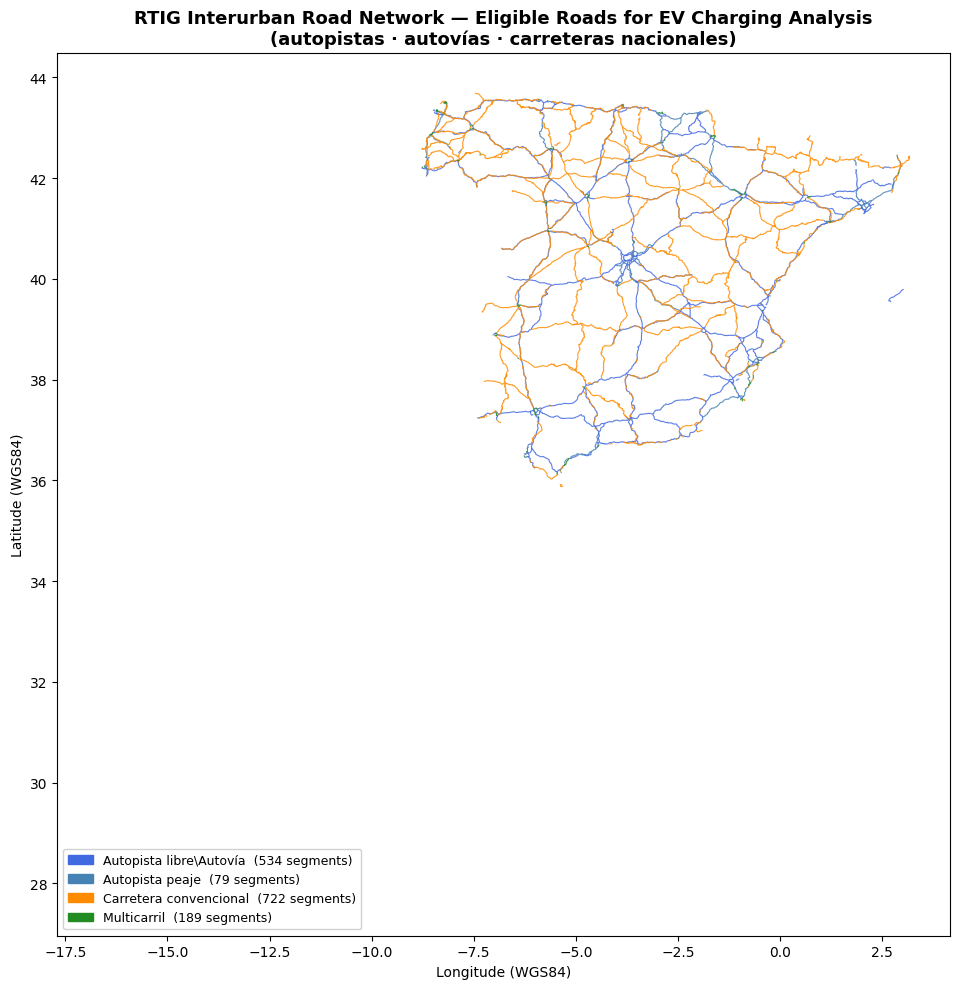

Map shows 1535 eligible segments across Spain.


In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

tipos  = sorted(gdf['Tipo_de_via'].dropna().unique())
colors = ['royalblue', 'steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']

handles = []
for i, tipo in enumerate(tipos):
    color  = colors[i % len(colors)]
    subset = gdf[gdf['Tipo_de_via'] == tipo]
    subset.plot(ax=ax, color=color, linewidth=0.8, alpha=0.85)
    handles.append(
        mpatches.Patch(color=color, label=f'{tipo}  ({len(subset)} segments)')
    )

ax.set_title(
    'RTIG Interurban Road Network — Eligible Roads for EV Charging Analysis\n'
    '(autopistas · autovías · carreteras nacionales)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')
ax.legend(handles=handles, loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f'Map shows {len(gdf)} eligible segments across Spain.')

## 7. Export to GeoJSON

Save the filtered, WGS84 GeoDataFrame to
`Data/raw/road_routes_spain/carreteras_RTIG.geojson`.

The `length_m` column is included — M4 will use it to place charging stations
at spacing intervals derived from the assumed EV autonomy range.

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

gdf.to_file(OUTPUT_PATH, driver='GeoJSON')

size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f'Saved   : {OUTPUT_PATH}')
print(f'Size    : {size_kb:.0f} KB')
print(f'Records : {len(gdf)}')

Saved   : ../Data/raw/road_routes_spain/carreteras_RTIG.geojson
Size    : 74620 KB
Records : 1535


## 8. Output Verification

Reload the exported file from disk and run assertions to confirm the output is
structurally correct before it is consumed by downstream notebooks (M4).

Per datathon evaluation criterion T5, all output file structures must be
printed and verified in the notebook.

In [10]:
gdf_v = gpd.read_file(OUTPUT_PATH)

print('OUTPUT VERIFICATION')
print('-' * 55)
print(f'  File            : carreteras_RTIG.geojson')
print(f'  Records         : {len(gdf_v)}')
print(f'  Columns         : {gdf_v.columns.tolist()}')
print(f'  CRS             : {gdf_v.crs}')
print(f'  Null geometries : {gdf_v.geometry.isna().sum()}')
print()
b = gdf_v.total_bounds   # [minx, miny, maxx, maxy]
print('  Bounding box:')
print(f'    Longitude : {b[0]:.3f}  →  {b[2]:.3f}')
print(f'    Latitude  : {b[1]:.3f}  →  {b[3]:.3f}')
print()
print('  Road type distribution:')
print(gdf_v['Tipo_de_via'].value_counts().to_string())
print('-' * 55)

# ── Assertions ───────────────────────────────────────────────────────────────
assert len(gdf_v) > 0, \
    'ERROR: output GeoJSON is empty'
assert gdf_v.crs.to_epsg() == 4326, \
    f'ERROR: expected EPSG:4326, got {gdf_v.crs}'
assert gdf_v.geometry.isna().sum() == 0, \
    'ERROR: null geometries found in output'
assert -20 < b[0] < 5,  f'ERROR: western bound {b[0]:.3f} outside Spain range'
assert  27 < b[1] < 44, f'ERROR: southern bound {b[1]:.3f} outside Spain range'
assert       b[2] < 5,  f'ERROR: eastern bound {b[2]:.3f} outside Spain range'
assert       b[3] < 45, f'ERROR: northern bound {b[3]:.3f} outside Spain range'

print('✓ Record count check passed')
print('✓ CRS check passed  (EPSG:4326 / WGS84)')
print('✓ Null geometry check passed')
print('✓ Coordinate bounds check passed (Spain)')
print()
print(f'→ Output ready for M4: {OUTPUT_PATH}')

OUTPUT VERIFICATION
-------------------------------------------------------
  File            : carreteras_RTIG.geojson
  Records         : 1535
  Columns         : ['id', 'Carretera', 'Longitud', 'PK_inicio', 'PK_fin', 'Tipo_de_via', 'Valido_desde', 'Valido_hasta', 'Titular', 'TENT', 'TENT_red_basica', 'TENT_corredor', 'length_m', 'geometry']
  CRS             : EPSG:4326
  Null geometries : 0

  Bounding box:
    Longitude : -16.710  →  3.168
    Latitude  : 27.757  →  43.691

  Road type distribution:
Tipo_de_via
Carretera convencional     722
Autopista libre\Autovía    534
Multicarril                189
Autopista peaje             79
-------------------------------------------------------
✓ Record count check passed
✓ CRS check passed  (EPSG:4326 / WGS84)
✓ Null geometry check passed
✓ Coordinate bounds check passed (Spain)

→ Output ready for M4: ../Data/raw/road_routes_spain/carreteras_RTIG.geojson
